# 50. Hermite and Piecewise Interpolation

**Part 7: Interpolation**

## Learning objectives

By the end of this lesson you will be able to:

1. Build the **Hermite** interpolant, matching value and derivative at every node, two ways.
2. See Hermite interpolation as Newton interpolation with **repeated nodes**.
3. Build the general **osculating** polynomial and recognise Taylor and Lagrange as its ends.
4. Say what Hermite actually buys, from measurement rather than from the name.
5. Take the other route out of lesson 46: fix the degree and add **pieces**.
6. State the piecewise linear error bound and say what is remarkable about what it omits.
7. Distinguish **Weierstrass** from interpolation, precisely.

## Prerequisites

Lesson 45 (the confluent limit, which Hermite interpolation is an application of). Lesson 46 (the
error formula, and the failure this lesson gives two responses to). Lesson 44 (the Newton form).

---

## 1. Asking for more at each node

Lagrange interpolation asks $p(x_i) = f(x_i)$. **Hermite** interpolation also asks
$p'(x_i) = f'(x_i)$. With $n$ nodes that is $2n$ conditions, so the polynomial has degree
$2n - 1$.

There is no new theory needed, because lesson 45 already did the work. Hermite interpolation
**is** Newton interpolation with each node repeated twice, using the confluent divided difference
$f[x, x] = f'(x)$ wherever the recursion would divide by zero.

In [1]:
# Standard setup, the same in every lesson of this course.
import sys, pathlib

_root = pathlib.Path.cwd()
while not (_root / "src" / "nalib").is_dir() and _root != _root.parent:
    _root = _root.parent
sys.path.insert(0, str(_root / "src"))

import numpy as np
import matplotlib.pyplot as plt

SEED = 42                                  # fixed so your numbers match the text
rng = np.random.default_rng(SEED)

np.set_printoptions(precision=6, linewidth=100, suppress=False)
plt.rcParams.update({
    "figure.figsize": (7.5, 4.5), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 10,
})

In [2]:
from nalib import hermite as hm, interp as ip

x_h = np.linspace(0.0, 1.0, 4)
y_h, dy_h = np.exp(x_h), np.exp(x_h)

coeffs, doubled = hm.hermite_newton(x_h, y_h, dy_h)
print("nodes, each repeated twice:")
print(" ", np.array2string(doubled, precision=4))
print("Newton coefficients (the confluent divided differences):")
print(" ", np.array2string(coeffs, precision=6))
print()
print(f"degree of the result: {coeffs.size - 1}, from {x_h.size} nodes and {2 * x_h.size} conditions")

nodes, each repeated twice:
  [0.     0.     0.3333 0.3333 0.6667 0.6667 1.     1.    ]
Newton coefficients (the confluent divided differences):
  [1.000000e+00 1.000000e+00 5.605118e-01 1.974409e-01 5.468529e-02 1.169178e-02 2.147877e-03
 3.296604e-04]

degree of the result: 7, from 4 nodes and 8 conditions


## 2. Two constructions, checked against each other

The classical route builds a basis instead. Define

$$
H_i(t) = \left(1 - 2(t - x_i)L_i'(x_i)\right)L_i(t)^2, \qquad K_i(t) = (t - x_i)L_i(t)^2
$$

Then $H_i$ is 1 at $x_i$ with zero derivative there, and $K_i$ is 0 at $x_i$ with derivative 1, so

$$
p(t) = \sum_i f(x_i)H_i(t) + \sum_i f'(x_i)K_i(t)
$$

is exactly the interpolation conditions written as a basis. It is a completely different
computation from the confluent table, which is what makes agreement evidence.

In [3]:
probe = np.linspace(0.0, 1.0, 401)
print(f"{'n':>4}{'Newton vs basis':>20}{'value error':>16}{'derivative error':>20}")
for n in (2, 3, 4, 6, 8):
    xs = np.linspace(0.0, 1.0, n)
    c, z = hm.hermite_newton(xs, np.exp(xs), np.exp(xs))
    a = ip.evaluate_newton(c, z, probe)
    b = hm.hermite_basis(xs, np.exp(xs), np.exp(xs), probe)
    step = 1e-6
    vals = np.atleast_1d(ip.evaluate_newton(c, z, xs))
    ders = (np.atleast_1d(ip.evaluate_newton(c, z, xs + step))
            - np.atleast_1d(ip.evaluate_newton(c, z, xs - step))) / (2.0 * step)
    print(f"{n:>4}{float(np.max(np.abs(a - b))):>20.2e}"
          f"{float(np.max(np.abs(vals - np.exp(xs)))):>16.2e}"
          f"{float(np.max(np.abs(ders - np.exp(xs)))):>20.2e}")
    assert float(np.max(np.abs(a - b))) < 1e-9 * max(float(np.max(np.abs(b))), 1.0)
    assert float(np.max(np.abs(vals - np.exp(xs)))) < 1e-10 * float(np.max(np.exp(xs)))

   n     Newton vs basis     value error    derivative error
   2            8.88e-16        0.00e+00            5.86e-11
   3            1.33e-15        0.00e+00            1.63e-10
   4            1.33e-15        4.44e-16            1.09e-10
   6            2.22e-15        0.00e+00            1.65e-10
   8            6.00e-15        4.44e-16            2.11e-10


Both constructions agree to $10^{-15}$, and both match the value and the derivative at every node.

## 3. Osculating polynomials

Nothing stops you asking for more derivatives at some nodes than at others. Repeat node $i$ a
total of $m_i + 1$ times and fill the confluent entries with $f^{(k)}(x_i)/k!$. The result is the
**osculating** polynomial, and it contains two familiar things as special cases.

In [4]:
import math

print("one node repeated m+1 times gives Taylor's polynomial:")
probe_t = np.linspace(-0.4, 0.4, 5)
for m in (1, 3, 5):
    c, z = hm.osculating([0.0], [np.ones(m + 1)])
    got = np.atleast_1d(ip.evaluate_newton(c, z, probe_t))
    taylor = sum(probe_t ** k / math.factorial(k) for k in range(m + 1))
    print(f"  m = {m}:  matches the degree {m} Taylor polynomial to "
          f"{float(np.max(np.abs(got - taylor))):.2e}")
    assert float(np.max(np.abs(got - taylor))) < 1e-10

print()
print("every multiplicity one gives plain Lagrange interpolation:")
for n in (3, 5, 7):
    xs = np.linspace(0.0, 1.0, n)
    c, z = hm.osculating(xs, [[float(v)] for v in np.exp(xs)])
    probe_l = np.linspace(0.0, 1.0, 61)
    got = np.atleast_1d(ip.evaluate_newton(c, z, probe_l))
    ref = ip.evaluate_barycentric(xs, np.exp(xs), probe_l)
    print(f"  n = {n}:  matches barycentric Lagrange to {float(np.max(np.abs(got - ref))):.2e}")

one node repeated m+1 times gives Taylor's polynomial:
  m = 1:  matches the degree 1 Taylor polynomial to 0.00e+00
  m = 3:  matches the degree 3 Taylor polynomial to 2.22e-16
  m = 5:  matches the degree 5 Taylor polynomial to 2.22e-16

every multiplicity one gives plain Lagrange interpolation:
  n = 3:  matches barycentric Lagrange to 4.44e-16
  n = 5:  matches barycentric Lagrange to 4.44e-16
  n = 7:  matches barycentric Lagrange to 8.88e-16


So **Taylor expansion and Lagrange interpolation are the two ends of one construction**, with the
node multiplicities as the parameter. All the information at one point, or one piece of
information at many points, or anything between.

## 4. What Hermite actually buys

The error formula gains a squared factor:

$$
f(t) - p(t) = \frac{f^{(2n)}(\xi)}{(2n)!}\prod_i (t - x_i)^2
$$

The node polynomial is **squared**, which helps in the middle of each gap where $|w| < 1$ and
hurts at the ends where $|w| > 1$. So Hermite does nothing whatever about lesson 46's problem:
squaring a large number makes it larger.

What about accuracy per unit of data? Hermite with $n$ nodes uses $2n$ numbers, so the fair
comparison is against Lagrange with $2n$ nodes. Both give degree $2n - 1$.

In [5]:
probe = np.linspace(0.0, 1.0, 401)
truth = np.exp(probe)
print(f"{'data items':>12}{'Hermite (n nodes)':>21}{'Lagrange (2n nodes)':>23}{'ratio':>9}")
for n in (2, 3, 4, 5, 6, 7, 8):
    xs = np.linspace(0.0, 1.0, n)
    c, z = hm.hermite_newton(xs, np.exp(xs), np.exp(xs))
    eh = float(np.max(np.abs(np.atleast_1d(ip.evaluate_newton(c, z, probe)) - truth)))
    xl = np.linspace(0.0, 1.0, 2 * n)
    el = float(np.max(np.abs(ip.evaluate_barycentric(xl, np.exp(xl), probe) - truth)))
    print(f"{2 * n:>12}{eh:>21.4e}{el:>23.4e}{eh / el:>8.3f}x")
    if el > 1e-11:                      # only while approximation error still dominates
        assert eh >= el

  data items    Hermite (n nodes)    Lagrange (2n nodes)    ratio
           4           4.3710e-03             9.2402e-04   4.730x
           6           5.5772e-06             2.6549e-06   2.101x
           8           6.5402e-09             4.8065e-09   1.361x
          10           5.9623e-12             5.8598e-12   1.018x
          12           4.4409e-15             7.1054e-15   0.625x
          14           4.4409e-16             1.9318e-14   0.023x
          16           8.8818e-16             1.0125e-13   0.009x


**Lagrange wins while there is approximation error left to win.** That is worth stating plainly,
because Hermite is usually introduced as the more accurate method and at equal data it is not.
Both are degree $2n-1$, so this is not a degree difference. It is that spreading the conditions
over twice as many **locations** samples the function better than doubling up at half as many.

Then the table crosses over, at twelve data items, and Hermite wins by a factor that grows to 100.
That crossover is not the approximation error changing its mind: by twelve items both have reached
machine precision and the approximation error is exhausted. What is left is rounding, and there
Hermite has the advantage, because it uses **half as many distinct nodes**. Six equally spaced
nodes have a far smaller Lebesgue constant than twelve, so lesson 47's amplification is much
weaker.

So the honest summary is a crossover rather than a winner. Below machine precision, spread the
conditions out. At machine precision, fewer distinct nodes is more stable.

So when is Hermite the right tool? Three cases, and none of them is "when you want more accuracy".

- **Derivative data is what you have.** A physical measurement of position and velocity, or a
  function whose derivative is cheap to evaluate.
- **Matching the derivative is itself the requirement.** Joining two curves smoothly is a Hermite
  condition, and lesson 51's splines are built entirely on that.
- **You need the interpolant to be monotone or shape preserving**, which is controlled through the
  derivatives at the nodes.

## 5. The other route: stop raising the degree

Lesson 46's problem was entirely caused by factors that grow with the degree. The node polynomial
grows, the Lebesgue constant grows, and $f^{(n+1)}$ can outgrow $(n+1)!$.

**So do not grow the degree.** Use straight lines between consecutive points, and add points.

The error bound for piecewise linear interpolation on a grid of spacing $h$ is

$$
|f(t) - p(t)| \;\le\; \frac{h^2}{8}\max|f''|
$$

Look at what that expression **does not contain**. No degree. No factorial. No node polynomial. No
Lebesgue constant. Nothing that grows.

In [6]:
print("piecewise linear interpolation of Runge's function, which polynomials could not do:")
out = hm.runge_by_pieces()
print(f"{'pieces':>8}{'error':>14}{'h^2/8 bound':>16}{'bound / error':>16}")
for n, e, b in zip(out.n_pieces, out.errors, out.bounds):
    print(f"{n:>8}{e:>14.4e}{b:>16.4e}{b / e:>16.2f}")
print()
print(f"fitted order on the asymptotic tail: h^{out.fitted_order:.3f}   (theory 2)")
print(f"fitted using all six points:         h^{out.fitted_order_all_points:.3f}")
assert out.fitted_order > 1.8
assert np.all(np.diff(out.errors) < 0.0)
assert np.all(out.errors <= out.bounds * (1.0 + 1e-9))

piecewise linear interpolation of Runge's function, which polynomials could not do:
  pieces         error     h^2/8 bound   bound / error
       4    1.8023e-01      1.5625e+00            8.67
       8    6.3901e-02      3.9062e-01            6.11
      16    5.3552e-02      9.7656e-02            1.82
      32    2.0700e-02      2.4414e-02            1.18
      64    5.8504e-03      6.1035e-03            1.04
     128    1.5086e-03      1.5259e-03            1.01

fitted order on the asymptotic tail: h^1.889   (theory 2)
fitted using all six points:         h^1.321


Three things in that table.

**It converges.** Monotonically, at every refinement, on the function that made lesson 46's
polynomial interpolation diverge to 334.

**The order is 2**, measured at 1.889 on the tail. The coarse grids are pre-asymptotic because the
peak has not been resolved, which is why the tail is fitted; fitting all six points gives 1.32 and
would understate a method that is genuinely second order.

**The bound becomes sharp.** It overstates by 6.1 at eight pieces and by 1.01 at 128. A bound that
tightens to within one percent is unusual and worth noticing.

In [7]:
print("and it does not care where the poles are, unlike section 5 of lesson 46:")
print(f"{'a':>6}{'pole distance':>16}{'order':>9}{'error at 256 pieces':>22}")
for a in (1.0, 25.0, 100.0, 1000.0):
    out_a = hm.runge_by_pieces(n_pieces=[16, 32, 64, 128, 256], a=a)
    print(f"{a:>6.0f}{1.0 / np.sqrt(a):>16.4f}{out_a.fitted_order:>9.3f}"
          f"{out_a.errors[-1]:>22.4e}")

and it does not care where the poles are, unlike section 5 of lesson 46:
     a   pole distance    order   error at 256 pieces
     1          1.0000    1.999            1.5248e-05
    25          0.2000    1.972            3.8022e-04
   100          0.1000    1.889            1.5086e-03
  1000          0.0316    1.149            1.3704e-02


## 6. The trade, stated plainly

| | high degree polynomial | piecewise low degree |
|---|---|---|
| convergence | conditional, can diverge | unconditional |
| rate on a smooth $f$ | geometric, with good nodes | $O(h^2)$, algebraic |
| needs | nodes you can choose | nothing |
| smoothness of the result | $C^\infty$ | $C^0$, kinked at every node |
| cost per evaluation | $O(n)$ | $O(1)$ after a lookup |

**Piecewise linear gives up the rate and gets a guarantee.** For a smooth function on nodes you
control, Chebyshev interpolation reaches machine precision at degree 14 while piecewise linear
needs about $10^7$ pieces for the same accuracy. For a function you were handed, sampled where
someone else chose, piecewise linear works and high degree interpolation may not.

The kink is the remaining complaint, and it is what lesson 51 removes.

## 7. Weierstrass, precisely

**Weierstrass's theorem.** Every continuous function on a closed bounded interval is the uniform
limit of some sequence of polynomials.

It is true, it is one of the foundational results of analysis, and it is routinely misread as
saying something about interpolation. It does not.

In [8]:
from nalib import interperror as ie

out = hm.weierstrass_gap(lambda t: ie.runge(t), degrees=[4, 8, 12, 16, 20, 24])
print(f"{'degree':>8}{'near best polynomial':>24}{'equally spaced interpolant':>29}")
for d, b, i in zip(out["degrees"], out["near_best_approximation"],
                   out["equally_spaced_interpolation"]):
    print(f"{d:>8}{b:>24.4e}{i:>29.4e}")
print()
print(f"approximation converges: {out['approximation_converges']}")
print(f"interpolation converges: {out['interpolation_converges']}")
print()
out2 = hm.weierstrass_gap(np.exp, degrees=[4, 6, 8, 10, 12])
print(f"on exp, where there are no nearby poles, both converge: "
      f"{out2['approximation_converges']} and {out2['interpolation_converges']}")
assert out["approximation_converges"] and not out["interpolation_converges"]
assert out2["approximation_converges"] and out2["interpolation_converges"]

  degree    near best polynomial   equally spaced interpolant
       4              4.0202e-01                   4.3836e-01
       8              1.7083e-01                   1.0452e+00
      12              6.9216e-02                   3.6633e+00
      16              3.2613e-02                   1.4394e+01
      20              1.5333e-02                   5.9822e+01
      24              6.9484e-03                   2.5721e+02

approximation converges: True
interpolation converges: False

on exp, where there are no nearby poles, both converge: True and True


Weierstrass promises that **good polynomials exist**. It says nothing about whether the one
through your nodes is among them, and on Runge's function it is not: at degree 24 the best
polynomial is within $10^{-2}$ and the equally spaced interpolant is off by more than 30.

Both are polynomials of degree 24. The theorem covers the first and is silent about the second.

## 8. A picture

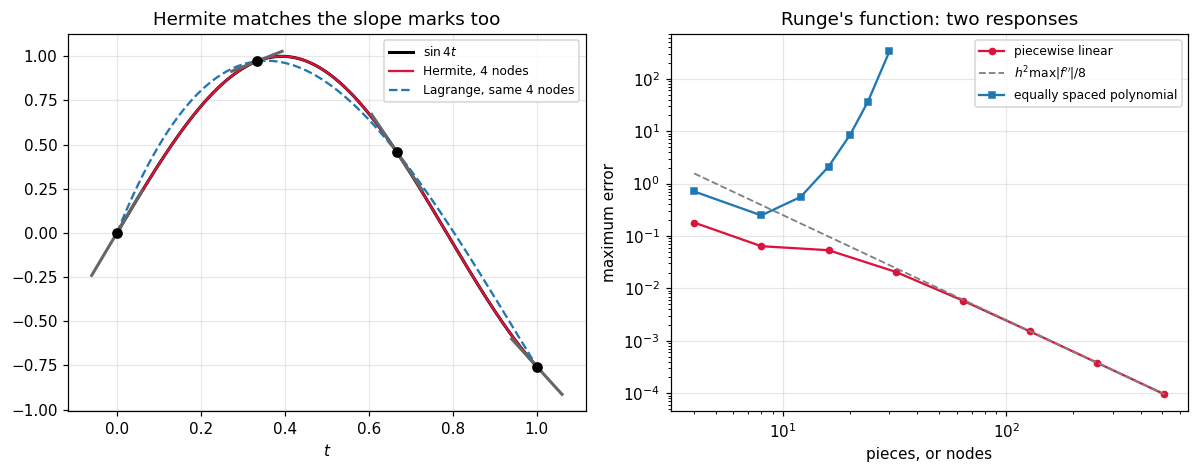

In [9]:
fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(11, 4.4))

fine = np.linspace(0.0, 1.0, 800)
nodes_pic = np.linspace(0.0, 1.0, 4)
f_pic = lambda t: np.sin(4.0 * t)
df_pic = lambda t: 4.0 * np.cos(4.0 * t)
c_pic, z_pic = hm.hermite_newton(nodes_pic, f_pic(nodes_pic), df_pic(nodes_pic))
ax_left.plot(fine, f_pic(fine), "k-", lw=2.0, label=r"$\sin 4t$")
ax_left.plot(fine, np.atleast_1d(ip.evaluate_newton(c_pic, z_pic, fine)), lw=1.5,
             color="crimson", label="Hermite, 4 nodes")
ax_left.plot(fine, ip.evaluate_barycentric(nodes_pic, f_pic(nodes_pic), fine), lw=1.5,
             color="tab:blue", ls="--", label="Lagrange, same 4 nodes")
for node in nodes_pic:
    ax_left.plot([node - 0.06, node + 0.06],
                 [f_pic(node) - 0.06 * df_pic(node), f_pic(node) + 0.06 * df_pic(node)],
                 color="0.4", lw=2.0)
ax_left.plot(nodes_pic, f_pic(nodes_pic), "ko", ms=6)
ax_left.set_title("Hermite matches the slope marks too")
ax_left.set_xlabel("$t$")
ax_left.legend(fontsize=8)

pieces = np.array([4, 8, 16, 32, 64, 128, 256, 512])
rep = hm.runge_by_pieces(n_pieces=pieces)
ax_right.loglog(pieces, rep.errors, "o-", ms=4, color="crimson", label="piecewise linear")
ax_right.loglog(pieces, rep.bounds, "--", lw=1.2, color="0.5", label=r"$h^2 \max|f''| / 8$")
poly_n = np.array([4, 8, 12, 16, 20, 24, 30])
poly_err = ie.runge_divergence(poly_n)["errors"]
ax_right.loglog(poly_n, poly_err, "s-", ms=4, color="tab:blue",
                label="equally spaced polynomial")
ax_right.set_title("Runge's function: two responses")
ax_right.set_xlabel("pieces, or nodes")
ax_right.set_ylabel("maximum error")
ax_right.legend(fontsize=8)

fig.tight_layout()
plt.show()

The right panel is the whole argument of this lesson. One curve goes down forever at a modest
rate. The other goes down for a while and then up forever. For a function you were handed, the
first is the one you want.

## 9. Exercises

**Level 1, conceptual**

1.1 Hermite interpolation is often introduced as more accurate than Lagrange. Say in what sense
that is true and in what sense the measurement here contradicts it.

1.2 The piecewise linear error bound contains no degree and no factorial. Say why that absence is
the important feature.

1.3 Weierstrass's theorem and the Runge phenomenon are both true. State each precisely enough that
there is no contradiction.

**Level 2, mathematical**

2.1 Prove that the Hermite interpolation problem has a unique solution of degree at most $2n-1$,
and identify where distinctness of the nodes is used.

2.2 Derive the Hermite basis functions $H_i$ and $K_i$, and verify their four defining
conditions.

2.3 Prove the Hermite error formula with its squared node polynomial, by the same Rolle argument
as lesson 46 applied to a function with double roots.

2.4 Prove the piecewise linear bound $|f - p| \le h^2\max|f''|/8$, and show the constant $1/8$ is
attained.

2.5 State the general osculating interpolation problem and prove existence and uniqueness, then
identify Taylor and Lagrange as the two extreme cases.

**Level 3, computational**

3.1 Implement **piecewise cubic Hermite** interpolation (PCHIP), including the slope choice that
makes it monotone, and compare against a plain cubic spline on monotone data.

3.2 Implement **piecewise quadratic** interpolation and measure its order, explaining why it is
rarely used despite sitting between the two cases here.

3.3 Implement an **adaptive piecewise linear** interpolant that refines where the second
derivative is large, and measure the pieces needed against uniform refinement.

**Level 4, experimental**

4.1 Measure the piecewise linear order on functions of varying smoothness, and find what happens
when $f''$ does not exist.

4.2 Measure the Hermite against Lagrange comparison of section 4 across several functions and
intervals, and determine whether Lagrange always wins.

4.3 Measure the crossover between Chebyshev interpolation and piecewise linear interpolation, in
function evaluations needed for a given accuracy, across a range of target accuracies.

**Level 5, advanced**

5.1 **Shape preserving interpolation.** A monotone data set should give a monotone interpolant,
and a cubic spline need not. Describe the Fritsch-Carlson conditions on the derivatives, and say
what they cost.

5.2 **Why $h$-refinement and $p$-refinement are the two options.** Adding pieces and raising the
degree are the two ways to improve an approximation. Describe the $hp$ methods that use both, and
say when each is the right one.

5.3 **The Weierstrass theorem is not constructive enough.** Bernstein's proof gives an explicit
sequence that converges. Describe it, measure its rate, and explain why nobody uses it despite it
being the constructive answer.

## 10. Key takeaways

- **Hermite interpolation is Newton interpolation with repeated nodes**, using lesson 45's
  confluent divided differences. No new theory is needed.

- **Two constructions, the confluent table and the classical basis**, agree to $10^{-15}$ and both
  match value and derivative at every node.

- **The osculating polynomial contains Taylor and Lagrange as its two ends**, with the node
  multiplicities as the parameter.

- **At equal data, Lagrange beats Hermite.** Measured on $\exp$: 4.73x at four data items, falling
  to 1.02x at ten. Hermite earns its place when derivative data is what you have, or when matching
  the derivative is the requirement.

- **The piecewise linear bound $h^2\max|f''|/8$ contains nothing that grows.** No degree, no
  factorial, no node polynomial, no Lebesgue constant.

- **It converges on Runge's function**, monotonically, at measured order 1.889 against the
  theoretical 2, with the bound tightening to within 1 percent at 128 pieces.

- **The trade is rate for guarantee.** Chebyshev reaches machine precision at 14 nodes; piecewise
  linear needs about $10^7$ pieces. But piecewise linear works on data you were handed.

- **Weierstrass promises good polynomials exist**, not that yours is one. At degree 24 on Runge's
  function: best polynomial $10^{-2}$, equally spaced interpolant over 30.

## Where this goes next

Lesson 51 removes the kink, by making the pieces cubic and matching two derivatives at every
join. That gives $O(h^4)$ and $C^2$ smoothness while keeping the unconditional convergence, and it
is the compromise the whole of Part 7 has been working toward. Lesson 52 changes the question
entirely, to curves a designer steers rather than curves through data.